# Network

In [ ]:
import pandas as pd

blocks_gdf = pd.read_pickle('./../data/blocks.pickle')
blocks_gdf.head(2)

,geometry,site_area,residential,business,recreation,industrial,transport,special,agriculture,land_use,...,capacity_prison,count_prison,capacity_landfill,count_landfill,capacity_plant_nursery,count_plant_nursery,capacity_greenhouse_complex,count_greenhouse_complex,capacity_warehouse,count_warehouse
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.032316,0.000,0.0,0.000000,0.0,1.000000,0.0,0.000000,LandUse.TRANSPORT,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",137101.088247,0.099,0.0,0.079912,0.0,0.401072,0.0,0.417018,LandUse.AGRICULTURE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Filter blocks getting only local ones for the example

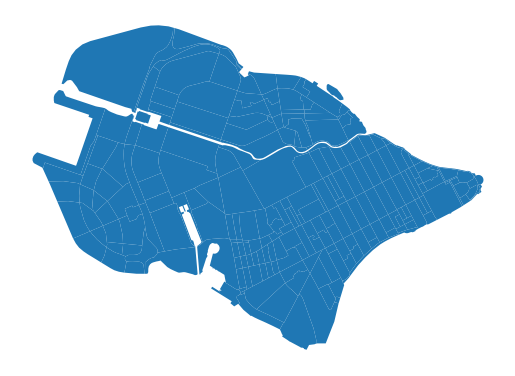

In [2]:
import osmnx as ox

local_crs = blocks_gdf.crs
polygon = ox.geocode_to_gdf('R1114252', by_osmid=True).to_crs(local_crs)
blocks_gdf = blocks_gdf[blocks_gdf.intersects(polygon.union_all())]
blocks_gdf.plot().set_axis_off()

In [3]:
blocks_gdf.population.sum()

np.float64(208763.0)

## Calculating accessibility matrices

In [4]:
from blocksnet.relations import get_accessibility_graph 

### Getting graphs

In [5]:
graph_drive = get_accessibility_graph(blocks_gdf, 'drive', additional_edgedata=["lanes"])

2026-02-25 13:54:55.793 | INFO     | iduedu.modules.drive_walk_builder:get_drive_graph_by_poly:91 - Downloading drive graph from OSM, it may take a while for large territory ...
2026-02-25 13:54:56.789 | WARNING  | iduedu.utils.utils:remove_weakly_connected_nodes:37 - Removing 28 nodes that form 27 trap components. These are groups where you can enter but can't exit (or vice versa). Keeping the largest strongly connected component (712 nodes).


In [6]:
graph_walk = get_accessibility_graph(blocks_gdf, 'walk')

2026-02-25 13:54:56.835 | INFO     | iduedu.modules.drive_walk_builder:get_walk_graph:217 - Downloading walk graph from OSM, it may take a while for large territory ...


Calculating the weights of the walk graph:   0%|          | 0/50982 [00:00<?, ?it/s]

### Calculating distances from `blocks` to `nodes`

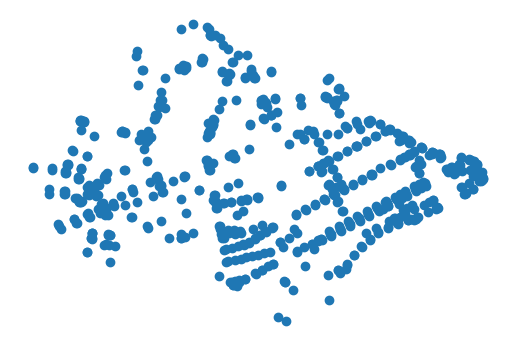

In [7]:
from blocksnet.relations import accessibility_graph_to_gdfs

nodes_gdf, _ = accessibility_graph_to_gdfs(graph_drive)
nodes_gdf.plot().set_axis_off()

In [8]:
from iduedu import get_adj_matrix_gdf_to_gdf

blocks_to_nodes = get_adj_matrix_gdf_to_gdf(blocks_gdf, nodes_gdf, graph_walk, weight='time_min')

In [9]:
blocks_to_nodes.head()

/Users/sashamorozov/Documents/Code/blocksnet_road_traffic/blocksnet/.venv/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,702,703,704,705,706,707,708,709,710,711
5,45.218750,47.562500,46.593750,46.625000,45.250000,49.687500,49.750000,47.343750,35.531250,41.156250,...,61.59375,63.25000,63.28125,63.71875,65.12500,60.93750,65.1250,65.25000,17.156250,19.906250
69,40.000000,44.437500,43.500000,43.500000,42.125000,47.625000,47.687500,44.437500,44.250000,49.812500,...,39.96875,41.03125,40.93750,41.37500,42.78125,39.31250,42.8125,42.90625,9.257812,8.242188
70,39.062500,43.531250,42.531250,42.562500,41.187500,46.718750,46.750000,43.531250,43.218750,48.750000,...,40.87500,41.90625,41.81250,42.25000,43.68750,40.21875,43.6875,43.81250,8.218750,7.312500
81,13.914062,14.382812,10.835938,10.851562,12.085938,7.480469,7.535156,10.179688,10.382812,4.500000,...,82.43750,84.06250,84.12500,86.18750,88.37500,81.75000,88.3750,88.50000,44.843750,45.125000
83,16.531250,18.750000,17.812500,17.828125,16.453125,21.734375,21.796875,18.546875,8.484375,14.109375,...,72.75000,74.43750,74.43750,75.50000,76.93750,72.12500,76.9375,77.06250,28.937500,31.703125


### Calculating distances from nodes to nodes

In [10]:
nodes_to_nodes = get_adj_matrix_gdf_to_gdf(nodes_gdf, nodes_gdf, graph_drive, weight='time_min')

In [11]:
nodes_to_nodes.head()

/Users/sashamorozov/Documents/Code/blocksnet_road_traffic/blocksnet/.venv/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,702,703,704,705,706,707,708,709,710,711
0,0.000000,0.020004,0.379883,0.320068,0.229980,0.680176,0.669922,0.360107,1.200195,1.530273,...,7.121094,7.328125,6.699219,6.789062,6.949219,6.851562,6.789062,6.800781,2.890625,2.650391
1,0.040009,0.000000,0.360107,0.300049,0.209961,0.660156,0.649902,0.340088,1.179688,1.509766,...,7.101562,7.308594,6.679688,6.769531,6.929688,6.828125,6.769531,6.781250,2.869141,2.630859
2,0.270020,0.290039,0.000000,0.010002,0.099976,0.370117,0.360107,0.049988,1.469727,1.219727,...,7.390625,7.601562,6.968750,7.058594,7.218750,7.121094,7.058594,7.070312,3.160156,2.919922
3,0.330078,0.350098,0.059998,0.000000,0.160034,0.360107,0.350098,0.040009,1.530273,1.209961,...,7.449219,7.660156,7.031250,7.121094,7.281250,7.179688,7.121094,7.128906,3.220703,2.980469
4,0.170044,0.189941,0.549805,0.489990,0.000000,0.850098,0.839844,0.529785,1.370117,1.700195,...,7.289062,7.500000,6.871094,6.960938,7.121094,7.019531,6.960938,6.968750,3.060547,2.820312


## Calculating OD matrix

In [12]:
from blocksnet.analysis.services import services_count

count_df = services_count(blocks_gdf)
count_df.head()

,count_school,count_kindergarten,count_hospital,count_polyclinic,count_pitch,count_swimming_pool,count_theatre,count_museum,count_cinema,count_mall,...,count_bus_station,count_bus_stop,count_pier,count_animal_shelter,count_prison,count_landfill,count_plant_nursery,count_greenhouse_complex,count_warehouse,count
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
70,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
81,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
83,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,13


In [13]:
from blocksnet.analysis.network import origin_destination_matrix

od_mx = origin_destination_matrix(blocks_gdf, blocks_to_nodes, nodes_to_nodes, count_df)

2026-02-25 13:55:07.457 | INFO     | blocksnet.analysis.network.origin_destination.core:_validate_input:132 - Validating input data
2026-02-25 13:55:07.457 | INFO     | blocksnet.analysis.network.origin_destination.core:_calculate_diversity:92 - Calculating diversity and density
2026-02-25 13:55:07.702 | INFO     | blocksnet.analysis.diversity.shannon.core:shannon_diversity:23 - Calculating Shannon diversity index
100%|██████████| 254/254 [00:00<00:00, 3755.10it/s]
2026-02-25 13:55:07.772 | INFO     | blocksnet.analysis.network.origin_destination.core:_calculate_attractiveness:100 - Calculating attractiveness
2026-02-25 13:55:07.774 | INFO     | blocksnet.analysis.network.origin_destination.core:_calculate_nodes_weights:73 - Identifying nearest nodes to blocks
2026-02-25 13:55:07.778 | INFO     | blocksnet.analysis.network.origin_destination.core:_calculate_nodes_weights:78 - Calculating weights
2026-02-25 13:55:07.783 | INFO     | blocksnet.analysis.network.origin_destination.core:_ca

In [14]:
od_mx

,0,1,2,3,4,5,6,7,8,9,...,702,703,704,705,706,707,708,709,710,711
0,0,14,1,1,2,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,1,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,18,2,1,1,4,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,4,0,2,1,1,5,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,2,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,0,0,0,0,1,1
708,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,27,1,1
709,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,1,3,0,1,1
710,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3


In [15]:
od_mx.sum().sum()

np.int64(208745)

## Calculating roads congestion

In [16]:
from blocksnet.analysis.network import road_congestion

graph_congestion = road_congestion(od_mx, graph_drive)

2026-02-25 13:55:07.934 | INFO     | blocksnet.analysis.network.road_congestion.core:road_congestion:173 - Preprocessing graph
2026-02-25 13:55:07.946 | INFO     | blocksnet.analysis.network.road_congestion.core:road_congestion:181 - Calculating shortest paths
100%|██████████| 712/712 [00:45<00:00, 15.70it/s]
2026-02-25 13:55:53.292 | INFO     | blocksnet.analysis.network.road_congestion.core:road_congestion:206 - Computing congestion level


In [17]:
_, edges_gdf = accessibility_graph_to_gdfs(graph_congestion)
edges_gdf.head()

length_meter  time_min  \
0 1          17.379     0.017   
1 343         8.024     0.008   
  344       224.415     0.224   
2 3           5.515     0.008   
  4          99.884     0.100   

                                                geometry  lanes  intensity  \
0 1    LINESTRING (348610.46 6648540.586, 348595.032 ...      2     1899.0   
1 343  LINESTRING (348595.032 6648548.588, 348588.653...      1     1001.0   
  344  LINESTRING (348595.032 6648548.588, 348581.331...      2      796.0   
2 3    LINESTRING (348859.015 6648442.978, 348857.583...      1      144.0   
  4    LINESTRING (348859.015 6648442.978, 348847.224...      2      764.0   

       capacity  congestion_level  
0 1      1900.0          0.999474  
1 343    1000.0          1.001000  
  344    1900.0          0.418947  
2 3      1000.0          0.144000  
  4      1900.0          0.402105

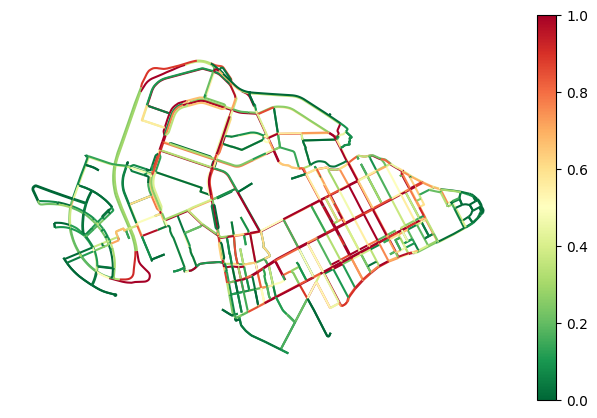

In [18]:
edges_gdf.plot('congestion_level',cmap="RdYlGn_r", legend=True, figsize=(8,5)).set_axis_off()